**Asignatura:** Inteligencia en Negocios Globales — Universidad EAN  
**Proyecto final — Grupo 1**  
**Producto:** Uchuva fresca (*Physalis peruviana*), subpartida nacional 0810905000. En las bases internacionales solo existe **HS 081090** ("otros frutos frescos"), que agrupa uchuva, maracuyá, pitahaya y otros; todos los indicadores se leen a ese nivel.  
**Ficha técnica de referencia:** *Equipo 1 — Ficha técnica* (septiembre de 2026). De los archivos entregados se usan los de HS 081090; los dos de HS 081020 (frambuesas y moras) corresponden a otro producto y no se usan. La serie 2016-2025 por destino se descargó de Trade Map para este cuaderno.

***

## La pregunta del equipo

> ¿Cómo puede Colombia fortalecer la competitividad de la uchuva y disminuir la dependencia de sus principales mercados de exportación?

## Lo que calcula este cuaderno

Cada sección corresponde a un análisis que el equipo propuso en su ficha técnica. El cuaderno **calcula y grafica; no interpreta**. La interpretación es el trabajo del equipo.

| Métrica o análisis | Pregunta que responde |
|---|---|
| **Participación de mercado por destino** | ¿A quién le vende Colombia la subpartida de la uchuva y con qué peso? |
| **CR3 y HHI** | ¿Qué tan concentradas están las exportaciones en pocos destinos, y cómo ha cambiado? |
| **Valor FOB por kilo** | ¿En qué destinos se paga mejor el producto? |
| **Crecimiento y CAGR** | ¿Qué destinos crecen y a qué ritmo? |
| **VCR de Balassa** | ¿Colombia exporta proporcionalmente más de este producto que el resto del mundo? |
| **PIB de los mercados candidatos** | ¿Qué tamaño tienen las economías a las que se quiere llegar? |
| **Matriz de mercados** | ¿Cuáles tres mercados se seleccionan entre al menos cinco candidatos? |

## Cómo usar este cuaderno

1. Ejecuta las celdas **en orden**, de arriba hacia abajo (`Entorno de ejecución → Ejecutar todas`). Viene en modo `"github"`: descarga sus propios datos del repositorio del curso, no tienes que subir nada.  
2. Después de cada gráfica hay una celda que dice **Análisis del equipo**. Haz doble clic sobre ella y escribe la interpretación. Puedes agregar más celdas de texto donde quieras.  
3. Las celdas marcadas **editable** contienen pesos o puntajes que el equipo debe ajustar con su propio criterio. Cámbialos y vuelve a ejecutar.  
4. Al terminar: `Archivo → Descargar → Descargar .ipynb` y sube el archivo al aula virtual.

Todas las tablas y figuras se guardan además en la carpeta `salidas/` (panel izquierdo de Colab) para que las uses en el informe.

***
# 0. Preparación del entorno

In [1]:
import os
import io
import csv
import glob
import time
import shutil
import zipfile
import urllib.request
import urllib.error
import urllib.parse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)

# Paleta de colores del curso (validada para lectura accesible en pantalla e impresion)
AZUL      = "#2a78d6"    # serie principal / pais del caso
ROJO      = "#e34948"    # valores negativos (par divergente con el azul)
NARANJA   = "#eb6834"    # elemento destacado
VERDE     = "#3f8f6b"    # segunda serie categorica
GRIS_MID  = "#c3c2b7"    # resto / punto neutro
TINTA     = "#0b0b0b"
GRIS_TEXT = "#52514e"
GRIS_EJE  = "#898781"
REJILLA   = "#e1e0d9"

# Orden fijo de colores para series categoricas: nunca se reciclan, lo que sobra va a "Otros" en gris
CATEGORIAS = [AZUL, NARANJA, VERDE, ROJO]

CARPETA_SALIDA = "salidas"
os.makedirs(CARPETA_SALIDA, exist_ok=True)


def estilo(ax, titulo, subtitulo="", fuente="", eje_y="", eje_x="", rejilla="y"):
    """Aplica el estilo de graficas del curso: titulo a la izquierda, sin marco, rejilla suave, fuente al pie."""
    ax.set_title(titulo + ("\n" + subtitulo if subtitulo else ""),
                 fontsize=13, color=TINTA, loc="left", pad=14)
    ax.set_ylabel(eje_y, fontsize=10, color=GRIS_TEXT)
    ax.set_xlabel(eje_x, fontsize=10, color=GRIS_TEXT)
    if rejilla == "y":
        ax.yaxis.grid(True, color=REJILLA, linewidth=0.8)
    elif rejilla == "x":
        ax.xaxis.grid(True, color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(GRIS_EJE)
    ax.tick_params(colors=GRIS_EJE, labelsize=9)
    if fuente:
        ax.figure.text(0.01, -0.03, "Fuente: " + fuente, fontsize=8, color=GRIS_EJE, ha="left")


def guardar(fig, nombre):
    """Muestra la figura y la guarda como PNG en la carpeta de salidas."""
    ruta = os.path.join(CARPETA_SALIDA, nombre + ".png")
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada en", ruta)


def exportar(tabla, nombre):
    """Guarda una tabla como CSV en la carpeta de salidas y la devuelve para mostrarla."""
    tabla.to_csv(os.path.join(CARPETA_SALIDA, nombre + ".csv"), index=False, encoding="utf-8-sig")
    return tabla


def fmt_miles(x, _=None):
    """Formato de eje para valores en miles de USD: 1200 -> 1.2 mn ; 850 -> 850 k."""
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.1f} mil mn"
    if abs(x) >= 1_000:
        return f"{x / 1_000:.1f} mn"
    return f"{x:.0f} k"


def fmt_unidades(x, _=None):
    """Formato de eje para valores en unidades: 1.5e9 -> 1.5 mil mn ; 2.4e6 -> 2.4 mn ; 850000 -> 850 k."""
    if abs(x) >= 1e9:
        return f"{x / 1e9:.1f} mil mn"
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f} mn"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.0f} k"
    return f"{x:.0f}"


def leyenda_fuera(ax):
    """Leyenda a la derecha del grafico, para que no tape barras ni la nota de fuente."""
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))


print("pandas:", pd.__version__, "| numpy:", np.__version__)

pandas: 2.2.3 | numpy: 2.1.3


In [2]:
# ============================================================
#  CONFIGURACION: cambia solo esta celda si lo necesitas
# ============================================================

MODO = "github"         # opciones: "github" | "subir" | "local"

REPO_CURSO = "YourFavouriteDataSuperstar/Inteligencia-de-negocios-globales"
RAMA = "main"

# Archivos que necesita este cuaderno, con su ruta dentro del repositorio del curso.
# Los del grupo estan en "Proyectos finales/Grupo 1/datos/"; los demas son datos del curso en "data/".
ARCHIVOS_REPO = {
    "exp_2025_xlsx": "Proyectos finales/Grupo 1/datos/colombias-exports-to-world-in-2025-by-importer_081090.xlsx",
    "imp_2025_xlsx": "Proyectos finales/Grupo 1/datos/colombias-imports-from-world-in-2025-by-exporter_081090.xlsx",
    "exp_serie": "Proyectos finales/Grupo 1/datos/colombias-exports-to-world-by-importer_081090.csv",
    "pib": "Proyectos finales/Grupo 1/datos/API_NY.GDP.MKTP.CD_DS2_es_csv_v2_35933/API_NY.GDP.MKTP.CD_DS2_es_csv_v2_35933.csv",
    "mundo_serie": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/03_datos_limpios/t2_exportadores_081090_largo.csv",
    "mundo_total": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/03_datos_limpios/t3_mundo_081090.csv",
    "canasta_co_exp": "data/co_exp_productos_hs2_serie.xls",
    "canasta_mundo_exp": "data/mundo_exp_productos_hs2_serie.csv",
}

RUTA_LOCAL = "../.."    # solo si MODO = "local": raiz del repositorio, corriendo desde la carpeta del grupo

print(f"Modo seleccionado: {MODO}  |  {len(ARCHIVOS_REPO)} archivos")

Modo seleccionado: github  |  8 archivos


In [3]:
# ============================================================
#  Ejecuta esta celda tal cual: consigue los datos segun el modo
# ============================================================

def pedir(url, intentos=5):
    """Descarga una URL, reintentando si el servidor pide esperar (HTTP 429 de GitHub en Colab)."""
    for intento in range(intentos):
        try:
            peticion = urllib.request.Request(url, headers={"User-Agent": "cuaderno-ean"})
            with urllib.request.urlopen(peticion, timeout=90) as respuesta:
                return respuesta.read()
        except urllib.error.HTTPError as error:
            if error.code not in (403, 429, 500, 502, 503) or intento == intentos - 1:
                raise
            espera = int(error.headers.get("Retry-After") or 0) or 2 ** intento
            print(f"    servidor ocupado (HTTP {error.code}); reintento en {espera} s")
            time.sleep(espera)
        except urllib.error.URLError:
            if intento == intentos - 1:
                raise
            time.sleep(2 ** intento)


def descargar_datos(rutas_repo, destino):
    """Trae los archivos del repositorio a la carpeta destino, en una sola peticion (zip del repo).

    Cada archivo se guarda por su nombre, sin carpetas. Si ya existe no se vuelve a bajar.
    Si el zip falla, baja los archivos uno por uno desde raw.githubusercontent.com.
    """
    os.makedirs(destino, exist_ok=True)
    faltan = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if not faltan:
        print(f"Los {len(rutas_repo)} archivos ya estaban descargados.")
        return
    try:
        print(f"Descargando {len(faltan)} archivos en una sola peticion...\n")
        comprimido = pedir(f"https://codeload.github.com/{REPO_CURSO}/zip/refs/heads/{RAMA}")
        with zipfile.ZipFile(io.BytesIO(comprimido)) as paquete:
            for miembro in paquete.namelist():
                relativo = miembro.split("/", 1)[1] if "/" in miembro else miembro
                if relativo in faltan:
                    with paquete.open(miembro) as origen, \
                         open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                        shutil.copyfileobj(origen, salida)
                    print(f"  extraido: {os.path.basename(relativo)}")
    except Exception as error:
        print(f"\n  El paquete fallo ({type(error).__name__}). Voy archivo por archivo.\n")
        for relativo in faltan:
            url = f"https://raw.githubusercontent.com/{REPO_CURSO}/{RAMA}/" + urllib.parse.quote(relativo)
            with open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                salida.write(pedir(url))
            print(f"  descargado: {os.path.basename(relativo)}")
            time.sleep(0.5)
    perdidos = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if perdidos:
        raise FileNotFoundError(f"No se pudieron descargar: {perdidos}. Espera un minuto y vuelve a ejecutar.")


if MODO == "github":
    RUTA_BASE = "datos_crudos"
    descargar_datos(list(ARCHIVOS_REPO.values()), RUTA_BASE)

    def ruta(clave):
        return os.path.join(RUTA_BASE, os.path.basename(ARCHIVOS_REPO[clave]))

elif MODO == "subir":
    from google.colab import files
    print("Sube estos archivos:\n  " + "\n  ".join(os.path.basename(v) for v in ARCHIVOS_REPO.values()))
    files.upload()
    RUTA_BASE = "/content"

    def ruta(clave):
        encontrados = glob.glob(os.path.join(RUTA_BASE, "**", os.path.basename(ARCHIVOS_REPO[clave])), recursive=True)
        if not encontrados:
            raise FileNotFoundError(f"Falta el archivo {os.path.basename(ARCHIVOS_REPO[clave])}")
        return encontrados[0]

else:  # local
    RUTA_BASE = RUTA_LOCAL

    def ruta(clave):
        return os.path.join(RUTA_BASE, ARCHIVOS_REPO[clave])

for clave in ARCHIVOS_REPO:
    estado = "ok" if os.path.exists(ruta(clave)) else "FALTA"
    print(f"  {estado:5s} {clave:14s} -> {os.path.basename(ARCHIVOS_REPO[clave])}")

Descargando 8 archivos en una sola peticion...

  extraido: API_NY.GDP.MKTP.CD_DS2_es_csv_v2_35933.csv
  extraido: colombias-exports-to-world-by-importer_081090.csv
  extraido: colombias-exports-to-world-in-2025-by-importer_081090.xlsx
  extraido: colombias-imports-from-world-in-2025-by-exporter_081090.xlsx
  extraido: t2_exportadores_081090_largo.csv
  extraido: t3_mundo_081090.csv
  extraido: co_exp_productos_hs2_serie.xls
  extraido: mundo_exp_productos_hs2_serie.csv
  ok    exp_2025_xlsx  -> colombias-exports-to-world-in-2025-by-importer_081090.xlsx
  ok    imp_2025_xlsx  -> colombias-imports-from-world-in-2025-by-exporter_081090.xlsx
  ok    exp_serie      -> colombias-exports-to-world-by-importer_081090.csv
  ok    pib            -> API_NY.GDP.MKTP.CD_DS2_es_csv_v2_35933.csv
  ok    mundo_serie    -> t2_exportadores_081090_largo.csv
  ok    mundo_total    -> t3_mundo_081090.csv
  ok    canasta_co_exp -> co_exp_productos_hs2_serie.xls
  ok    canasta_mundo_exp -> mundo_exp_product

In [4]:
# ============================================================
#  Lectores: cada funcion resuelve las trampas de un tipo de archivo
# ============================================================

def a_numero(serie):
    """Convierte a numero una columna que viene como texto (miles con coma, simbolos, espacios)."""
    return pd.to_numeric(
        pd.Series(serie).astype(str)
                        .str.replace(",", "", regex=False)
                        .str.replace(r"[^0-9.\-]", "", regex=True)
                        .replace("", np.nan),
        errors="coerce",
    )


# Nombres cortos en espanol para las columnas de Trade Map
COLUMNAS_TM = {
    "Value (kUSD)": "valor_kusd",
    "Balance (kUSD)": "balanza_kusd",
    "Quantity": "cantidad",
    "Quantity Unit": "unidad_cantidad",
    "Unit Value": "valor_unitario",
    "Unit Value Unit": "unidad_valor_unitario",
    "Share (%)": "participacion_pct",
    "Share Partner Country (%)": "cuota_en_socio_pct",
    "Share World (%)": "participacion_mundial_pct",
    "Ranking Partners": "ranking_socio",
    "Growth Value 5Y (%)": "crec_valor_5a_pct",
    "Growth Value 2Y (%)": "crec_valor_2a_pct",
    "Growth Value Partners 5Y (%)": "crec_importaciones_socio_5a_pct",
    "Growth Quantity 5Y (%)": "crec_cantidad_5a_pct",
}

AGREGADOS_NO_PAIS = ["Zona franca", "Zonas francas", "Áreas Nes", "Areas, nes", "Zona Nep", "Free Zones"]


def leer_trademap(ruta_archivo):
    """Lee una tabla de indicadores de Trade Map (corte de un anio, formato largo).

    Trampas que resuelve: una columna sin nombre en el encabezado, codigos de pais con cero
    inicial que pandas convertiria a entero, valor unitario con 28 decimales, y la fila
    "Mundo" mezclada con los paises. La columna `pais` queda lista para usar.
    """
    tabla = pd.read_csv(ruta_archivo, dtype={"reporterCd": str, "partnerCd": str, "productCd": str},
                        encoding="utf-8-sig")
    return limpiar_trademap(tabla)


def limpiar_trademap(tabla):
    """Limpieza comun a toda tabla de indicadores de Trade Map, venga de CSV o de Excel."""
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    for columna in ("reporterCd", "partnerCd"):
        tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
    tabla = tabla.rename(columns=COLUMNAS_TM)
    for columna in COLUMNAS_TM.values():
        if columna in tabla.columns and columna not in ("unidad_cantidad", "unidad_valor_unitario"):
            tabla[columna] = a_numero(tabla[columna])
    if "valor_unitario" in tabla.columns:
        tabla["valor_unitario"] = tabla["valor_unitario"].round(2)
    # Si todos los socios son "Mundo", la tabla es una lista de paises (reporter); si no, es una lista de socios
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    return tabla


def separar_mundo(tabla):
    """Devuelve (fila Mundo, tabla solo con paises). Excluye agregados que no son paises."""
    es_mundo = tabla["codigo"] == "000"
    mundo = tabla[es_mundo].iloc[0]
    paises = tabla[~es_mundo & ~tabla["pais"].isin(AGREGADOS_NO_PAIS)].reset_index(drop=True)
    return mundo, paises


def leer_serie_trademap(ruta_archivo):
    """Lee la serie anual por socio (un anio por columna) y la devuelve en formato largo.

    Columnas de salida: codigo, pais, anio, valor_kusd. Incluye la fila Mundo (codigo 000).
    """
    tabla = pd.read_csv(ruta_archivo, dtype=str, encoding="utf-8-sig")
    columnas_anio = [c for c in tabla.columns if c[:4].isdigit()]
    tabla = tabla.rename(columns={c: c[:4] for c in columnas_anio})
    anios = [c[:4] for c in columnas_anio]
    for anio in anios:
        tabla[anio] = a_numero(tabla[anio])
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    largo = tabla.melt(id_vars=["codigo", "pais"], value_vars=anios, var_name="anio", value_name="valor_kusd")
    largo["anio"] = largo["anio"].astype(int)
    return largo.sort_values(["anio", "valor_kusd"], ascending=[True, False]).reset_index(drop=True)


def leer_banco_mundial(ruta_archivo, nombre_indicador):
    """Lee un archivo del Banco Mundial: cuatro filas de metadatos antes del encabezado y un anio por columna."""
    tabla = pd.read_csv(ruta_archivo, skiprows=4, encoding="utf-8-sig")
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    anios = [c for c in tabla.columns if c.isdigit()]
    largo = tabla.melt(id_vars=["Country Name", "Country Code"], value_vars=anios,
                       var_name="anio", value_name=nombre_indicador)
    largo["anio"] = largo["anio"].astype(int)
    return largo.rename(columns={"Country Name": "pais", "Country Code": "iso3"})


ANIOS_CANASTA = [str(a) for a in range(2021, 2026)]


def leer_canasta(ruta_archivo):
    """Lee la canasta por capitulo HS del curso (97 capitulos + TOTAL, 2021-2025).

    Funciona igual si el archivo es un .csv o un .xls que en realidad es HTML.
    Trampas: apostrofe delante del codigo y miles separados por coma como texto.
    """
    with open(ruta_archivo, encoding="utf-8", errors="ignore") as f:
        primeras_letras = f.read(200).lstrip().lower()
    if primeras_letras.startswith("<"):
        tabla = max(pd.read_html(ruta_archivo), key=lambda t: t.shape[0])
    else:
        tabla = pd.read_csv(ruta_archivo)
    tabla = tabla.iloc[:, -7:]
    tabla.columns = ["codigo", "producto"] + ANIOS_CANASTA
    tabla["codigo"] = tabla["codigo"].astype(str).str.strip().str.lstrip("'").str.strip()
    for anio in ANIOS_CANASTA:
        tabla[anio] = a_numero(tabla[anio])
    return tabla.dropna(subset=["2025"]).reset_index(drop=True)


def fila_canasta(canasta, codigo):
    """Devuelve la serie 2021-2025 (en USD miles) de un codigo de la canasta: un capitulo HS2 o "TOTAL"."""
    fila = canasta[canasta["codigo"] == codigo]
    if fila.empty:
        raise KeyError(f"No encontre el codigo {codigo} en la canasta")
    return fila.iloc[0][ANIOS_CANASTA].astype(float)


print("Lectores listos.")

Lectores listos.


In [5]:
# ============================================================
#  Formulas: las mismas de los cuadernos 2, 3 y 4 del curso
# ============================================================

def hhi(valores):
    """Indice de Herfindahl-Hirschman: suma de participaciones al cuadrado. Entre 0 y 1."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[~np.isnan(valores)]
    valores = valores[valores > 0]
    if valores.sum() == 0:
        return np.nan
    participaciones = valores / valores.sum()
    return float(np.sum(participaciones ** 2))


def numeros_equivalentes(indice_hhi):
    """Cuantos destinos del mismo tamano equivaldrian a esta reparticion: 1 / HHI."""
    return 1 / indice_hhi

def cr_n(valores, n):
    """Razon de concentracion CR_n: participacion conjunta (%) de los n mayores."""
    valores = np.sort(np.asarray(valores, dtype=float))[::-1]
    valores = valores[~np.isnan(valores)]
    return float(valores[:n].sum() / valores.sum() * 100)

def rca_balassa(x_pais, x_pais_total, x_mundo, x_mundo_total):
    """Ventaja Comparativa Revelada de Balassa (1965). Mayor que 1 = especializacion revelada."""
    participacion_pais  = np.asarray(x_pais, dtype=float)  / np.asarray(x_pais_total, dtype=float)
    participacion_mundo = np.asarray(x_mundo, dtype=float) / np.asarray(x_mundo_total, dtype=float)
    return participacion_pais / participacion_mundo


def rsca_laursen(rca):
    """RCA simetrico de Laursen: (RCA - 1) / (RCA + 1), entre -1 y +1, con 0 como punto neutro."""
    rca = np.asarray(rca, dtype=float)
    return (rca - 1) / (rca + 1)

def cagr(valor_inicial, valor_final, anios):
    """Tasa de crecimiento anual compuesto (%) entre dos valores separados por `anios` anios."""
    valor_inicial, valor_final = float(valor_inicial), float(valor_final)
    if valor_inicial <= 0 or valor_final <= 0 or anios <= 0:
        return np.nan
    return ((valor_final / valor_inicial) ** (1 / anios) - 1) * 100

def matriz_multicriterio(puntajes, pesos):
    """Pondera una tabla de puntajes (filas = criterios, columnas = mercados) con un diccionario de pesos.

    Devuelve la contribucion de cada criterio por mercado y el total, ordenado de mayor a menor.
    Los pesos se normalizan para que sumen 1, asi que puedes escribirlos en % o en fracciones.
    """
    pesos = pd.Series(pesos, dtype=float)
    pesos = pesos / pesos.sum()
    contribucion = puntajes.mul(pesos, axis=0)
    resultado = contribucion.T
    resultado["Total"] = resultado.sum(axis=1)
    return resultado.sort_values("Total", ascending=False)

print('Formulas listas.')

Formulas listas.


***
# 1. Los datos y una trampa nueva

El archivo de exportaciones 2025 llegó como `.xlsx`, pero cada fila tiene el texto completo de una línea CSV metido en una sola celda, y con la codificación dañada (`maracuyÃ¡`). El lector de abajo reconstruye el texto, repara la codificación y lo interpreta como CSV. El archivo de importaciones sí está bien tabulado.

In [6]:
def leer_trademap_xlsx_roto(ruta_archivo):
    """Reconstruye una tabla de Trade Map cuyo xlsx trae una linea CSV completa por celda."""
    import openpyxl
    libro = openpyxl.load_workbook(ruta_archivo, read_only=True)
    hoja = libro.active
    lineas = [str(fila[0]) for fila in hoja.iter_rows(values_only=True) if fila and fila[0] is not None]
    texto = "\n".join(lineas)
    try:
        texto = texto.encode("latin-1").decode("utf-8")      # repara "maracuyÃ¡" -> "maracuyá"
    except UnicodeError:
        pass
    tabla = pd.read_csv(io.StringIO(texto), dtype={"reporterCd": str, "partnerCd": str, "productCd": str})
    return limpiar_trademap(tabla)


def leer_trademap_xlsx(ruta_archivo):
    """Lee una tabla de Trade Map guardada como Excel normal."""
    tabla = pd.read_excel(ruta_archivo, dtype={"reporterCd": str, "partnerCd": str, "productCd": str})
    return limpiar_trademap(tabla)


exp_2025 = leer_trademap_xlsx_roto(ruta("exp_2025_xlsx"))
imp_2025 = leer_trademap_xlsx(ruta("imp_2025_xlsx"))
serie    = leer_serie_trademap(ruta("exp_serie"))
mundo_serie = pd.read_csv(ruta("mundo_serie"), dtype={"codigo_tm": str})      # exportadores mundiales 2016-2025 (grupo 6)
mundo_total = pd.read_csv(ruta("mundo_total"))                                  # el mundo, 2016-2025
canasta_co_exp    = leer_canasta(ruta("canasta_co_exp"))
canasta_mundo_exp = leer_canasta(ruta("canasta_mundo_exp"))

mundo_2025, destinos_2025 = separar_mundo(exp_2025)
mundo_imp_2025, origenes_2025 = separar_mundo(imp_2025)
print(f"Colombia exporto HS 081090 por USD {mundo_2025['valor_kusd']:,.0f} miles en 2025 ({mundo_2025['cantidad']:,.0f} t) a {len(destinos_2025)} destinos")
print(f"Colombia importo HS 081090 por USD {mundo_imp_2025['valor_kusd']:,.0f} miles, sobre todo de {origenes_2025.iloc[0]['pais']}")
destinos_2025[["pais", "valor_kusd", "cantidad", "valor_unitario", "participacion_pct", "cuota_en_socio_pct", "crec_valor_5a_pct", "crec_importaciones_socio_5a_pct"]].head(10)

Colombia exporto HS 081090 por USD 116,451 miles en 2025 (22,955 t) a 35 destinos
Colombia importo HS 081090 por USD 2,886 miles, sobre todo de Ecuador


/tmp/ipykernel_3040/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_3040/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_3040/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

,pais,valor_kusd,cantidad,valor_unitario,participacion_pct,cuota_en_socio_pct,crec_valor_5a_pct,crec_importaciones_socio_5a_pct
0,Países Bajos,"76,271.0000","14,765.0000","5,165.6600",65.4962,25.7075,4.0000,-4.0000
1,Reino Unido,"7,985.0000","1,630.0000","4,898.7700",6.8570,6.9718,40.0000,15.0000
2,Alemania,"7,237.0000","1,389.0000","5,210.2200",6.2146,11.5098,21.0000,13.0000
3,Estados Unidos de América,"6,222.0000","1,280.0000","4,860.9400",5.3430,0.2020,6.0000,6.0000
4,Canadá,"4,700.0000","1,139.0000","4,126.4300",4.0360,4.7269,-1.0000,10.0000
5,España,"3,084.0000",635.0000,"4,856.6900",2.6483,12.5376,10.0000,26.0000
6,Bélgica,"2,623.0000",479.0000,"5,475.9900",2.2524,0.4080,1.0000,6.0000
7,Emiratos Árabes Unidos,"2,011.0000",356.0000,"5,648.8800",1.7269,1.7695,1.0000,18.0000
8,Brasil,"1,380.0000",302.0000,"4,569.5400",1.1850,20.2010,20.0000,39.0000
9,Francia,"1,273.0000",210.0000,"6,061.9000",1.0932,4.5397,-8.0000,7.0000


In [7]:
pib = leer_banco_mundial(ruta("pib"), "pib_usd")
pib.dropna().groupby("anio").size().tail(3)   # cuantos paises tienen dato en los ultimos anios

,0
anio,
2023,249
2024,245
2025,231


***
# 2. Participación de mercado por destino

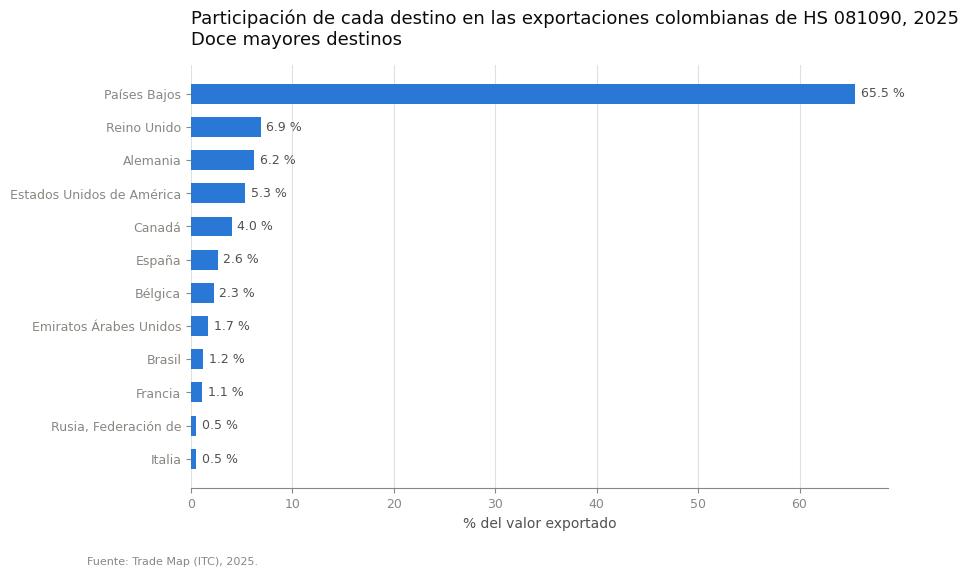

Figura guardada en salidas/g1_participacion_2025.png


,pais,valor_kusd,cantidad,participacion_pct
0,Países Bajos,"76,271.0000","14,765.0000",65.4962
1,Reino Unido,"7,985.0000","1,630.0000",6.8570
2,Alemania,"7,237.0000","1,389.0000",6.2146
3,Estados Unidos de América,"6,222.0000","1,280.0000",5.3430
4,Canadá,"4,700.0000","1,139.0000",4.0360
5,España,"3,084.0000",635.0000,2.6483
6,Bélgica,"2,623.0000",479.0000,2.2524
7,Emiratos Árabes Unidos,"2,011.0000",356.0000,1.7269
8,Brasil,"1,380.0000",302.0000,1.1850
9,Francia,"1,273.0000",210.0000,1.0932


In [8]:
participacion = destinos_2025.nlargest(12, "valor_kusd")[["pais", "valor_kusd", "cantidad", "participacion_pct"]]
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = participacion.sort_values("participacion_pct")
ax.barh(orden["pais"], orden["participacion_pct"], color=AZUL, height=0.6)
for y, v in enumerate(orden["participacion_pct"]):
    ax.annotate(f"{v:.1f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Participación de cada destino en las exportaciones colombianas de HS 081090, 2025", "Doce mayores destinos",
       "Trade Map (ITC), 2025.", eje_x="% del valor exportado", rejilla="x")
guardar(fig, "g1_participacion_2025")
exportar(participacion, "g1_participacion_2025")

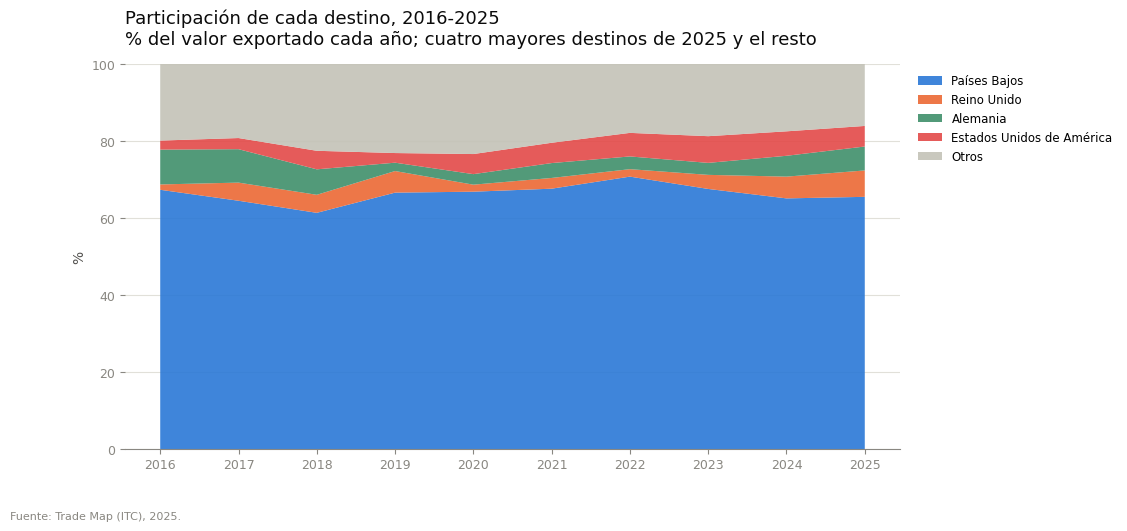

Figura guardada en salidas/g1_participacion_serie.png


grupo,Países Bajos,Reino Unido,Alemania,Estados Unidos de América,Otros
anio,,,,,
2016,67.3000,1.4000,9.0000,2.3000,19.9000
2017,64.5000,4.7000,8.7000,2.9000,19.2000
2018,61.3000,4.7000,6.6000,4.8000,22.5000
2019,66.6000,5.6000,2.2000,2.5000,23.1000
2020,66.8000,1.8000,2.7000,5.2000,23.4000
2021,67.6000,2.8000,3.9000,5.3000,20.5000
2022,70.7000,1.9000,3.3000,6.1000,17.9000
2023,67.5000,3.7000,3.1000,6.9000,18.7000
2024,65.1000,5.7000,5.4000,6.4000,17.5000


In [9]:
paises_serie = serie[serie["codigo"] != "000"]
top4 = paises_serie[paises_serie["anio"] == 2025].nlargest(4, "valor_kusd")["pais"].tolist()
series_top = (paises_serie.assign(grupo=lambda d: np.where(d["pais"].isin(top4), d["pais"], "Otros"))
                          .groupby(["anio", "grupo"])["valor_kusd"].sum().unstack("grupo")[top4 + ["Otros"]])
participacion_serie = series_top.div(series_top.sum(axis=1), axis=0) * 100
exportar(participacion_serie.reset_index(), "g1_participacion_serie")

fig, ax = plt.subplots(figsize=(10, 5))
colores = CATEGORIAS + [GRIS_MID]
ax.stackplot(participacion_serie.index, [participacion_serie[c] for c in participacion_serie.columns], colors=colores, labels=participacion_serie.columns, alpha=0.9)
ax.set_ylim(0, 100)
ax.set_xticks(participacion_serie.index)
leyenda_fuera(ax)
estilo(ax, "Participación de cada destino, 2016-2025", "% del valor exportado cada año; cuatro mayores destinos de 2025 y el resto", "Trade Map (ITC), 2025.", eje_y="%")
guardar(fig, "g1_participacion_serie")
participacion_serie.round(1)

**Análisis del equipo:** ¿Qué tan dependiente es el producto de un solo comprador y desde cuándo?

En 2025 Colombia exportó USD 116,5 millones de HS 081090, y Países Bajos se llevó el 65,5 % (USD 76,3 millones). Muy por detrás quedan Reino Unido (6,9 %), Alemania (6,2 %) y Estados Unidos (5,3 %). Aunque hubo 35 destinos, el negocio está prácticamente en manos de uno solo.

La gráfica de 2016 a 2025 muestra que esto no es nuevo. La participación de Países Bajos se movió siempre entre 61 % y 71 %, y terminó la década casi igual que como empezó. Es una dependencia de largo plazo, no el resultado de un año atípico.

Vale la pena mirar también los valores en dólares, porque el porcentaje puede engañar. El grupo "Otros" bajó de 19,9 % a 16,1 %, pero en realidad creció de USD 11,3 a 18,7 millones. Lo que pasó fue que Países Bajos creció más rápido todavía (de 38,4 a 76,3 millones). Es decir, no se perdieron mercados: el principal simplemente creció más. El caso contrario es Reino Unido, que pasó de USD 0,8 a 8,0 millones.

Hay un detalle importante para interpretar bien la cifra: Países Bajos es el gran puerto de entrada de fruta fresca a Europa, y Trade Map registra a dónde se despacha la carga, no dónde se consume. Es posible que parte de ese 65,5 % se reexporte a otros países europeos. Habría que confirmarlo con datos de reexportación antes de afirmarlo.

***
# 3. Concentración: CR3 y HHI, 2016-2025

In [10]:
concentracion = (paises_serie.groupby("anio")["valor_kusd"]
                 .agg(HHI=hhi, CR3=lambda v: cr_n(v, 3), destinos_activos=lambda v: int((v > 0).sum()))
                 .reset_index())
concentracion["numero_equivalente"] = numeros_equivalentes(concentracion["HHI"])
exportar(concentracion, "g1_concentracion")
concentracion

,anio,HHI,CR3,destinos_activos,numero_equivalente
0,2016,0.4670,80.6234,34,2.1413
1,2017,0.4304,77.8756,34,2.3233
2,2018,0.3916,73.1576,36,2.5539
3,2019,0.4552,77.9159,37,2.1969
4,2020,0.4593,78.8353,34,2.1771
5,2021,0.4675,78.0761,41,2.1390
6,2022,0.5101,81.6630,31,1.9603
7,2023,0.4687,79.9252,39,2.1334
8,2024,0.4377,77.0998,35,2.2846
9,2025,0.4439,78.5685,32,2.2528


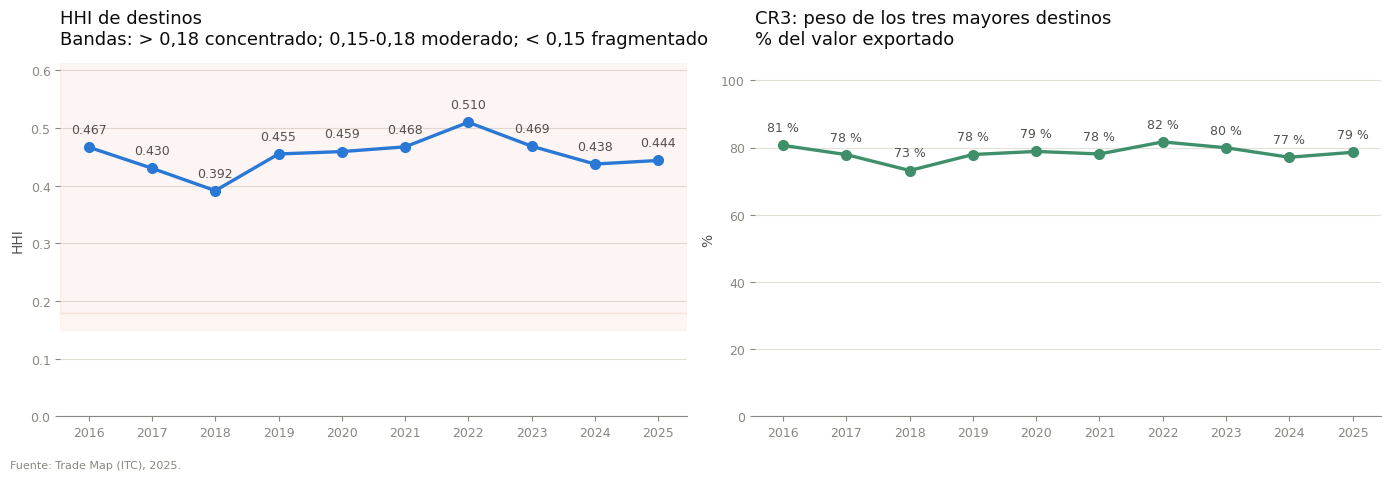

Figura guardada en salidas/g1_concentracion.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(concentracion["anio"], concentracion["HHI"], color=AZUL, linewidth=2.4, marker="o", markersize=7)
for _, fila in concentracion.iterrows():
    axes[0].annotate(f"{fila['HHI']:.3f}", (fila["anio"], fila["HHI"]), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].axhspan(0.18, 1, color=ROJO, alpha=0.06)
axes[0].axhspan(0.15, 0.18, color=NARANJA, alpha=0.06)
axes[0].set_ylim(0, max(0.6, concentracion["HHI"].max() * 1.2))
axes[0].set_xticks(concentracion["anio"])
estilo(axes[0], "HHI de destinos", "Bandas: > 0,18 concentrado; 0,15-0,18 moderado; < 0,15 fragmentado", eje_y="HHI")
axes[1].plot(concentracion["anio"], concentracion["CR3"], color=VERDE, linewidth=2.4, marker="o", markersize=7)
for _, fila in concentracion.iterrows():
    axes[1].annotate(f"{fila['CR3']:.0f} %", (fila["anio"], fila["CR3"]), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXT)
axes[1].set_ylim(0, 105)
axes[1].set_xticks(concentracion["anio"])
estilo(axes[1], "CR3: peso de los tres mayores destinos", "% del valor exportado", "Trade Map (ITC), 2025.", eje_y="%")
plt.tight_layout()
guardar(fig, "g1_concentracion")

**Análisis del equipo:**

El HHI de destinos se movió entre 0,392 (2018) y 0,510 (2022), y cerró en 0,444 en 2025. Todos los años de la serie están muy por encima del umbral de 0,18, de modo que las exportaciones colombianas de HS 081090 se clasifican como altamente concentradas durante toda la década, sin excepción. El CR3 confirma la lectura: los tres mayores destinos nunca bajaron de 73,2 % ni subieron de 81,7 %, y en 2025 se llevaron 78,6 % del valor.

El indicador más elocuente es el número equivalente: 2,25 en 2025. Aunque Colombia le vendió a 32 destinos activos ese año, la repartición del valor se comporta como si existieran apenas dos compradores del mismo tamaño. La brecha entre 32 destinos nominales y 2,25 destinos efectivos es la medida exacta de la fragilidad del portafolio.

Comparar el número de destinos con el HHI año a año desmonta una intuición común. En 2021 Colombia llegó a 41 destinos, el máximo de la serie, y el HHI fue 0,4675: prácticamente idéntico al de 2016, cuando eran 34. Abrir mercados nuevos no diversificó nada, porque los destinos que se suman son de tamaño marginal. La diversificación no se mide en cuántas banderas hay en el mapa sino en cuánto valor se desplaza fuera del destino principal, y ese desplazamiento no ha ocurrido. Nótese además que 2022, el año de mayor concentración (HHI 0,510; CR3 81,7 %), coincide con el menor número de destinos activos (31), lo que sugiere que el portafolio largo se contrae justo cuando el destino principal se expande.

***
# 4. Valor FOB por kilo

Trade Map entrega `valor_unitario` en USD por tonelada: se divide por 1.000 para tenerlo en USD por kilo.

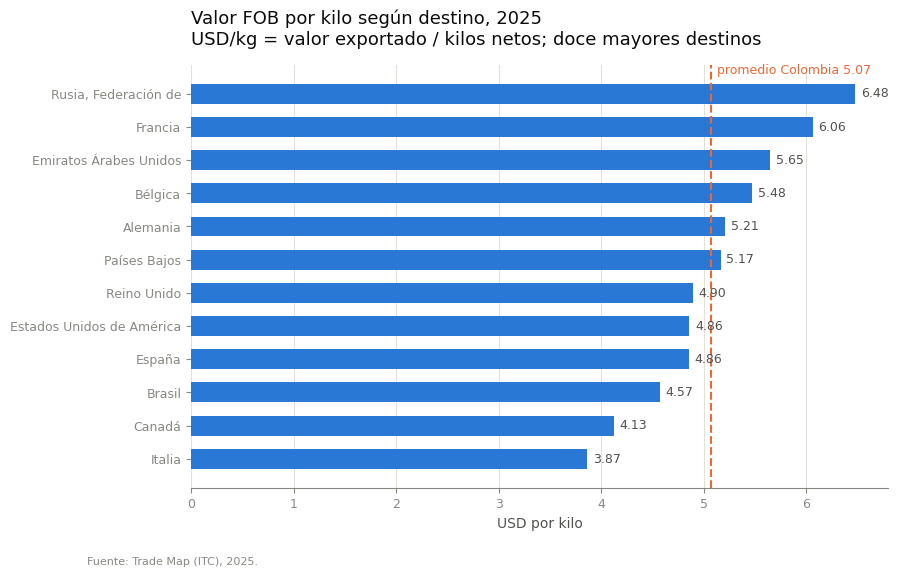

Figura guardada en salidas/g1_fob_por_kilo.png


,pais,valor_kusd,cantidad,fob_usd_kg
0,Países Bajos,"76,271.0000","14,765.0000",5.1657
1,Reino Unido,"7,985.0000","1,630.0000",4.8988
2,Alemania,"7,237.0000","1,389.0000",5.2102
3,Estados Unidos de América,"6,222.0000","1,280.0000",4.8609
4,Canadá,"4,700.0000","1,139.0000",4.1264
5,España,"3,084.0000",635.0000,4.8567
6,Bélgica,"2,623.0000",479.0000,5.4760
7,Emiratos Árabes Unidos,"2,011.0000",356.0000,5.6489
8,Brasil,"1,380.0000",302.0000,4.5695
9,Francia,"1,273.0000",210.0000,6.0619


In [12]:
fob_kg = destinos_2025.nlargest(12, "valor_kusd").copy()
fob_kg = fob_kg[fob_kg["cantidad"] > 0]
fob_kg["fob_usd_kg"] = fob_kg["valor_unitario"] / 1000
promedio_kg = mundo_2025["valor_unitario"] / 1000
fob_kg = fob_kg[["pais", "valor_kusd", "cantidad", "fob_usd_kg"]]
exportar(fob_kg, "g1_fob_por_kilo")
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = fob_kg.sort_values("fob_usd_kg")
ax.barh(orden["pais"], orden["fob_usd_kg"], color=AZUL, height=0.6)
ax.axvline(promedio_kg, color=NARANJA, linewidth=1.5, linestyle="--")
ax.annotate(f"promedio Colombia {promedio_kg:.2f}", (promedio_kg, len(orden) - 0.4), xytext=(4, 0), textcoords="offset points", fontsize=9, color=NARANJA)
for y, v in enumerate(orden["fob_usd_kg"]):
    ax.annotate(f"{v:.2f}", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Valor FOB por kilo según destino, 2025", "USD/kg = valor exportado / kilos netos; doce mayores destinos",
       "Trade Map (ITC), 2025.", eje_x="USD por kilo", rejilla="x")
guardar(fig, "g1_fob_por_kilo")
fob_kg

**Análisis del equipo:**

⁠Valor FOB por kilo: indica en qué destinos el mismo kilogramo de fruta se vende más caro. Es la diferencia entre “vender más” y “vender mejor”: dos mercados pueden comprar el mismo volumen, pero si uno paga más por kilo, genera más ingreso con el mismo esfuerzo logístico y productivo.  
Este indicador es clave para decidir dónde conviene invertir en presentación, certificación o marca, porque revela qué mercados ya están dispuestos a pagar un precio superior. El promedio de Colombia en 2025 es de USD 5,07 por kilo.  
Los destinos que pagan por encima del promedio son Rusia (6,48), Francia (6,06), Emiratos Árabes Unidos (5,65), Bélgica (5,48) y Alemania (5,21). Países Bajos —el mercado dominante en volumen— se ubica justo en el promedio (5,17): no es un mercado que pague un precio diferenciado, es simplemente el más grande. Por debajo del promedio quedan Reino Unido, Estados Unidos, España, Brasil, Canadá e Italia, este último el más bajo de la lista (3,87).

Este comportamiento de Países Bajos es consistente con su papel estructural en el comercio europeo: el país no es únicamente un consumidor final, sino la principal plataforma de reexportación de fruta fresca hacia el resto de Europa, gracias al puerto de Rotterdam y a la concentración de centros de distribución en su territorio (Centre for the Promotion of Imports from Developing Countries [CBI], s.f.; Rodríguez, 2025). Eso explica por qué el precio pagado allí se comporta como un precio de tránsito mayorista y no como el de un mercado final dispuesto a pagar un diferencial por calidad.  
La lectura de negocio es directa: la dependencia de Países Bajos no está siquiera compensada por un mejor precio. Si el objetivo del proyecto es agregar valor —no solo volumen—, los mercados que ya pagan más por kilo (Emiratos Árabes Unidos, Alemania, Bélgica) son los primeros candidatos para invertir en mejor empaque, certificaciones o una propuesta de producto diferenciada, porque son mercados que ya demuestran disposición a pagar más por la misma fruta. Esta brecha de valor agregado no es nueva: un estudio de mercado sobre la cadena de la uchuva colombiana ya documentaba que, mientras los mayoristas del norte de Europa pagaban entre USD 4,80 y 6,39 por kilo, el precio recibido por el productor en Colombia era de apenas USD 0,84 por kilo, evidenciando que la mayor parte del margen se queda en la cadena de comercialización externa y no en el origen (Arias Vargas & Rendón Sierra, 2015).

***
# 5. Crecimiento y CAGR por destino

In [13]:
ancho = paises_serie.pivot(index="pais", columns="anio", values="valor_kusd")
top10 = ancho[2025].nlargest(10).index
tabla_cagr = pd.DataFrame({
    "valor_2016": ancho.loc[top10, 2016],
    "valor_2020": ancho.loc[top10, 2020],
    "valor_2025": ancho.loc[top10, 2025],
    "cagr_2016_2025_pct": [cagr(ancho.loc[p, 2016], ancho.loc[p, 2025], 9) for p in top10],
    "cagr_2020_2025_pct": [cagr(ancho.loc[p, 2020], ancho.loc[p, 2025], 5) for p in top10],
}).reset_index()
total = serie[serie["codigo"] == "000"].set_index("anio")["valor_kusd"]
print(f"CAGR total HS 081090 2016-2025: {cagr(total[2016], total[2025], 9):.1f} %   |   2020-2025: {cagr(total[2020], total[2025], 5):.1f} %")
exportar(tabla_cagr, "g1_cagr")
tabla_cagr

CAGR total HS 081090 2016-2025: 8.3 %   |   2020-2025: 8.6 %


,pais,valor_2016,valor_2020,valor_2025,cagr_2016_2025_pct,cagr_2020_2025_pct
0,Países Bajos,38406,51416,76271,7.9212,8.2062
1,Reino Unido,792,1401,7985,29.2723,41.6339
2,Alemania,5161,2106,7237,3.8278,28.0030
3,Estados Unidos de América,1338,4014,6222,18.6216,9.1618
4,Canadá,2423,4658,4700,7.6395,0.1797
5,España,767,1731,3084,16.7203,12.2441
6,Bélgica,1982,4574,2623,3.1624,-10.5253
7,Emiratos Árabes Unidos,454,676,2011,17.9824,24.3635
8,Brasil,1165,934,1380,1.8996,8.1201
9,Francia,1495,1759,1273,-1.7703,-6.2627


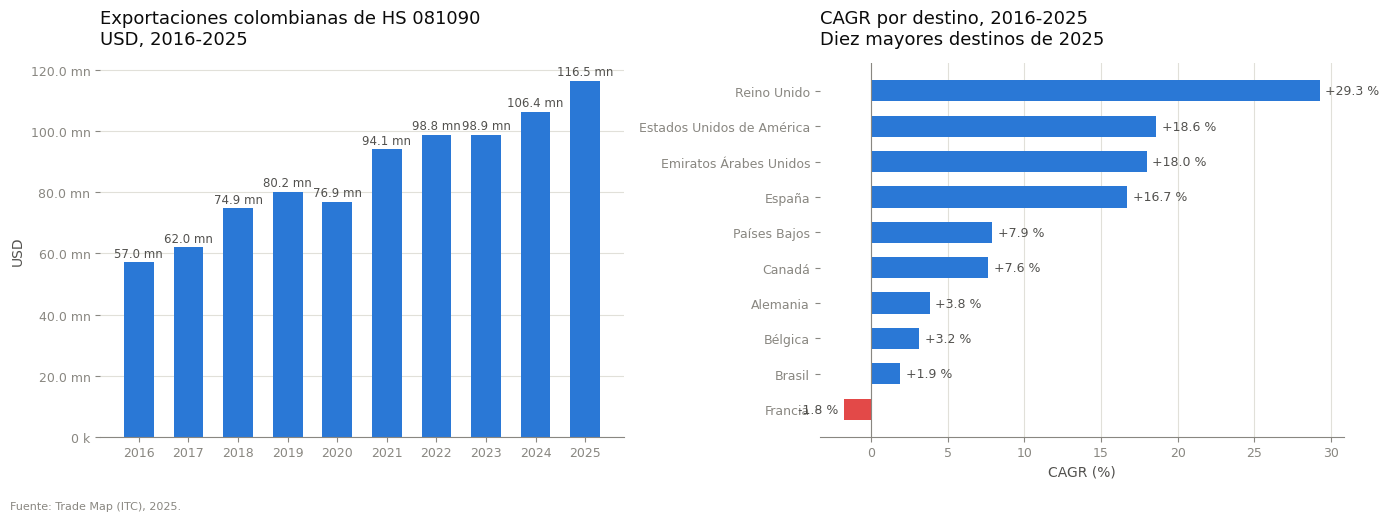

Figura guardada en salidas/g1_crecimiento.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(total.index.astype(str), total.values, color=AZUL, width=0.6)
for x, v in enumerate(total.values):
    axes[0].annotate(fmt_miles(v), (x, v), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8.5, color=GRIS_TEXT)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
estilo(axes[0], "Exportaciones colombianas de HS 081090", "USD, 2016-2025", eje_y="USD")
orden = tabla_cagr.sort_values("cagr_2016_2025_pct")
colores = [ROJO if v < 0 else AZUL for v in orden["cagr_2016_2025_pct"]]
axes[1].barh(orden["pais"], orden["cagr_2016_2025_pct"], color=colores, height=0.6)
for y, v in enumerate(orden["cagr_2016_2025_pct"]):
    axes[1].annotate(f"{v:+.1f} %", (v, y), textcoords="offset points", xytext=(4 if v >= 0 else -4, 0), ha="left" if v >= 0 else "right", va="center", fontsize=9, color=GRIS_TEXT)
axes[1].axvline(0, color=GRIS_EJE, linewidth=0.8)
estilo(axes[1], "CAGR por destino, 2016-2025", "Diez mayores destinos de 2025", "Trade Map (ITC), 2025.", eje_x="CAGR (%)", rejilla="x")
plt.tight_layout()
guardar(fig, "g1_crecimiento")

**Análisis del equipo:**

Crecimiento y CAGR por Destino: El total exportado puede subir de un año a otro simplemente porque el mercado más grande compró un poco más, mientras otros destinos se estancan o caen. El CAGR por destino calculado sobre un periodo de varios años (en este caso 2016-2025) muestra el ritmo real y sostenido de cada mercado, sin el ruido de un solo año atípico, y permite identificar hacia dónde se está moviendo la demanda.  
Las exportaciones totales de la subpartida pasaron de USD 57,0 millones en 2016 a USD 116,5 millones en 2025, con un CAGR de 8,3 % (8,6 % si se mide solo 2020-2025, es decir, el crecimiento se aceleró levemente en el periodo reciente). Pero ese crecimiento agregado esconde comportamientos muy distintos por destino: Reino Unido crece a 29,3 % anual, Estados Unidos a 18,6 %, Emiratos Árabes Unidos a 18,0 % y España a 16,7 %. En el otro extremo, Francia es el único destino en declive (-1,8 %), y Países Bajos, pese a seguir siendo el mercado dominante, solo crece al 7,9 % anual, es decir, al ritmo del mercado en general: no está ganando participación relativa, simplemente mantiene su tamaño.  
Cruzando esto con el precio por kilo: Emiratos Árabes Unidos combina crecimiento alto (18,0 %) con un precio por encima del promedio (5,65 USD/kg), lo que lo convierte en el candidato más atractivo para priorizar. Este hallazgo no depende solo de la serie histórica de Colombia: informes independientes de mercado proyectan que el sector de frutas y hortalizas de los Emiratos Árabes Unidos seguirá creciendo a un ritmo anual cercano al 4,6-7,5 % hacia 2029-2031, impulsado por el turismo, la hostelería de alta gama y la baja producción local de fruta (Mordor Intelligence, 2024), lo que sugiere que el crecimiento observado en la demanda de uchuva colombiana en ese destino responde a una tendencia estructural y no a un año atípico. Estados Unidos y Reino Unido crecen aún más rápido, pero pagan por debajo del promedio, por lo que su atractivo depende de que el proyecto logre subir el precio percibido mediante valor agregado. Francia merece atención porque es un mercado que paga bien pero se está perdiendo, lo cual amerita investigar la causa antes de descartarlo.

***
# 6. Ventaja comparativa revelada de Balassa

Numerador: exportaciones colombianas de HS 081090 (Trade Map) y exportaciones mundiales del mismo código (serie del grupo 6, también de Trade Map). Denominador: exportaciones totales de Colombia y del mundo, fila TOTAL de la canasta HS2 del curso. Se calcula también para el capítulo 08 completo (frutas) con la serie 2021-2025.

Ojo: la cobertura mundial de 2025 en Trade Map es parcial (no todos los países han reportado), por eso se muestran 2024 y 2025.

In [15]:
vcr = []
for anio in (2024, 2025):
    X_ij = total[anio]
    X_i  = fila_canasta(canasta_co_exp, "TOTAL")[str(anio)]
    X_j  = mundo_total.set_index("anio").loc[anio, "exportaciones_mundiales_usd_miles"]
    X_w  = fila_canasta(canasta_mundo_exp, "TOTAL")[str(anio)]
    r = float(rca_balassa(X_ij, X_i, X_j, X_w))
    vcr.append({"anio": anio, "X_ij": X_ij, "X_i": X_i, "X_j": X_j, "X_w": X_w, "RCA_081090": r, "RSCA_081090": float(rsca_laursen(r))})
vcr = pd.DataFrame(vcr)

vcr_cap08 = pd.DataFrame({"anio": [int(a) for a in ANIOS_CANASTA]})
vcr_cap08["RCA_cap08"] = rca_balassa(fila_canasta(canasta_co_exp, "08"), fila_canasta(canasta_co_exp, "TOTAL"),
                                     fila_canasta(canasta_mundo_exp, "08"), fila_canasta(canasta_mundo_exp, "TOTAL"))
vcr_cap08["RSCA_cap08"] = rsca_laursen(vcr_cap08["RCA_cap08"])
exportar(vcr, "g1_rca_081090"); exportar(vcr_cap08, "g1_rca_cap08")
display(vcr); vcr_cap08

,anio,X_ij,X_i,X_j,X_w,RCA_081090,RSCA_081090
0,2024,106407,"49,551,988.0000","3,904,393.0000","23,931,014,145.0000",13.1618,0.8588
1,2025,116451,"50,172,751.0000","3,209,449.0000","25,609,329,378.0000",18.5201,0.8975


,anio,RCA_cap08,RSCA_cap08
0,2021,5.2593,0.6805
1,2022,4.5814,0.6417
2,2023,4.4095,0.6303
3,2024,5.4063,0.6878
4,2025,6.2188,0.7229


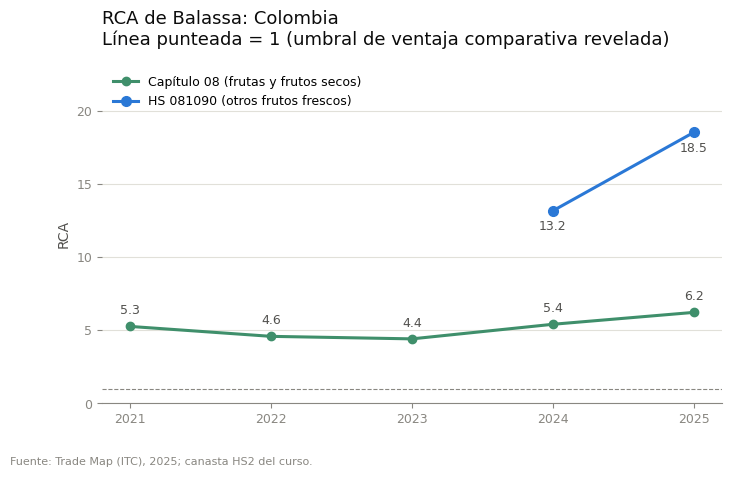

Figura guardada en salidas/g1_rca.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(vcr_cap08["anio"], vcr_cap08["RCA_cap08"], color=VERDE, linewidth=2.2, marker="o", markersize=6, label="Capítulo 08 (frutas y frutos secos)")
ax.plot(vcr["anio"], vcr["RCA_081090"], color=AZUL, linewidth=2.2, marker="o", markersize=7, label="HS 081090 (otros frutos frescos)")
for _, f in vcr_cap08.iterrows():
    ax.annotate(f"{f['RCA_cap08']:.1f}", (f["anio"], f["RCA_cap08"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=GRIS_TEXT)
for _, f in vcr.iterrows():
    ax.annotate(f"{f['RCA_081090']:.1f}", (f["anio"], f["RCA_081090"]), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=9, color=GRIS_TEXT)
ax.axhline(1, color=GRIS_EJE, linewidth=0.8, linestyle="--")
ax.set_xticks(vcr_cap08["anio"])
ax.set_ylim(0, max(vcr_cap08["RCA_cap08"].max(), vcr["RCA_081090"].max()) * 1.25)
ax.legend(frameon=False, fontsize=9, loc="upper left")
estilo(ax, "RCA de Balassa: Colombia", "Línea punteada = 1 (umbral de ventaja comparativa revelada)", "Trade Map (ITC), 2025; canasta HS2 del curso.", eje_y="RCA")
guardar(fig, "g1_rca")

**Análisis del equipo:** ¿La ventaja es del producto o de toda la fruticultura colombiana? ¿Qué implica que HS 081090 mezcle varias frutas?

La gráfica muestra que Colombia presenta una ventaja comparativa revelada tanto en el capítulo 08, correspondiente a frutas y frutos secos, como en el código HS 081090. Esto se puede afirmar porque todos los resultados del índice RCA están por encima de 1, que es el valor utilizado para identificar si un país tiene una especialización exportadora en un producto o sector.

En el caso del capítulo 08, el RCA fue de 5,26 en 2021, disminuyó hasta 4,41 en 2023 y después volvió a aumentar hasta 5,41 en 2024 y 6,22 en 2025. Esto demuestra que Colombia tiene una ventaja exportadora en el sector de frutas en general y que esta ventaja se fortaleció durante los dos últimos años analizados.

Para el código HS 081090, la ventaja es todavía mayor, pues el RCA pasó de 13,16 en 2024 a 18,52 en 2025. Esto significa que los productos incluidos en este código tienen una participación mucho mayor dentro de las exportaciones colombianas que dentro de las exportaciones mundiales. Por lo tanto, Colombia muestra una especialización importante en este grupo de frutos frescos.

Sin embargo, esta ventaja no puede atribuirse completamente a la uchuva, ya que el HS 081090 reúne diferentes frutas frescas. Además, los datos mundiales de 2025 tienen una cobertura parcial, porque no todos los países habían entregado su información. Por esta razón, el crecimiento del RCA debe interpretarse con cuidado y complementarse con datos específicos sobre la uchuva, sus destinos, precios y crecimiento de la demanda.

El resultado respalda la decisión de mantener y explorar la expansión internacional de la uchuva colombiana, debido a la fortaleza exportadora del sector frutícola. Sin embargo, la selección del mercado no debe depender solamente del RCA, sino también de la demanda, la participación de Colombia, los precios y los requisitos de entrada de cada país.

***
# 7. PIB de los mercados candidatos

Los candidatos se toman de los mayores destinos de 2025. La lista es **editable**: cambia los pares `nombre en Trade Map: código ISO3` para evaluar otros mercados.

In [17]:
# ====================== EDITABLE: mercados candidatos (nombre Trade Map -> ISO3) ======================
CANDIDATOS = {
    "Países Bajos": "NLD", "Reino Unido": "GBR", "Alemania": "DEU", "Estados Unidos de América": "USA",
    "Canadá": "CAN", "España": "ESP", "Bélgica": "BEL", "Emiratos Árabes Unidos": "ARE",
}
# ======================================================================================================
pib_reciente = (pib.dropna(subset=["pib_usd"]).sort_values("anio").groupby("iso3").tail(1)
                   .set_index("iso3")[["pais", "anio", "pib_usd"]].rename(columns={"pais": "pais_bm", "anio": "anio_pib"}))
tablero = destinos_2025.set_index("pais").reindex(CANDIDATOS.keys())[
    ["valor_kusd", "participacion_pct", "cuota_en_socio_pct", "ranking_socio", "crec_valor_5a_pct", "crec_importaciones_socio_5a_pct", "valor_unitario"]]
tablero["iso3"] = pd.Series(CANDIDATOS)
tablero = tablero.join(pib_reciente, on="iso3")
tablero["pib_usd_mil_mn"] = tablero["pib_usd"] / 1e9
exportar(tablero.reset_index(), "g1_tablero_candidatos")
tablero

,valor_kusd,participacion_pct,cuota_en_socio_pct,ranking_socio,crec_valor_5a_pct,crec_importaciones_socio_5a_pct,valor_unitario,iso3,pais_bm,anio_pib,pib_usd,pib_usd_mil_mn
pais,,,,,,,,,,,,
Países Bajos,"76,271.0000",65.4962,25.7075,3.0000,4.0000,-4.0000,"5,165.6600",NLD,Países Bajos,2025,"1,332,767,651,100.3899","1,332.7677"
Reino Unido,"7,985.0000",6.8570,6.9718,7.0000,40.0000,15.0000,"4,898.7700",GBR,Reino Unido,2025,"4,002,587,541,846.0098","4,002.5875"
Alemania,"7,237.0000",6.2146,11.5098,4.0000,21.0000,13.0000,"5,210.2200",DEU,Alemania,2025,"5,050,922,925,047.0498","5,050.9229"
Estados Unidos de América,"6,222.0000",5.3430,0.2020,2.0000,6.0000,6.0000,"4,860.9400",USA,Estados Unidos,2025,"30,769,700,000,000.0000","30,769.7000"
Canadá,"4,700.0000",4.0360,4.7269,9.0000,-1.0000,10.0000,"4,126.4300",CAN,Canadá,2025,"2,319,899,772,425.9199","2,319.8998"
España,"3,084.0000",2.6483,12.5376,21.0000,10.0000,26.0000,"4,856.6900",ESP,España,2025,"1,906,453,309,985.8799","1,906.4533"
Bélgica,"2,623.0000",2.2524,0.4080,15.0000,1.0000,6.0000,"5,475.9900",BEL,Bélgica,2025,"725,466,462,859.6460",725.4665
Emiratos Árabes Unidos,"2,011.0000",1.7269,1.7695,10.0000,1.0000,18.0000,"5,648.8800",ARE,Emiratos Árabes Unidos,2024,"552,324,919,095.8719",552.3249


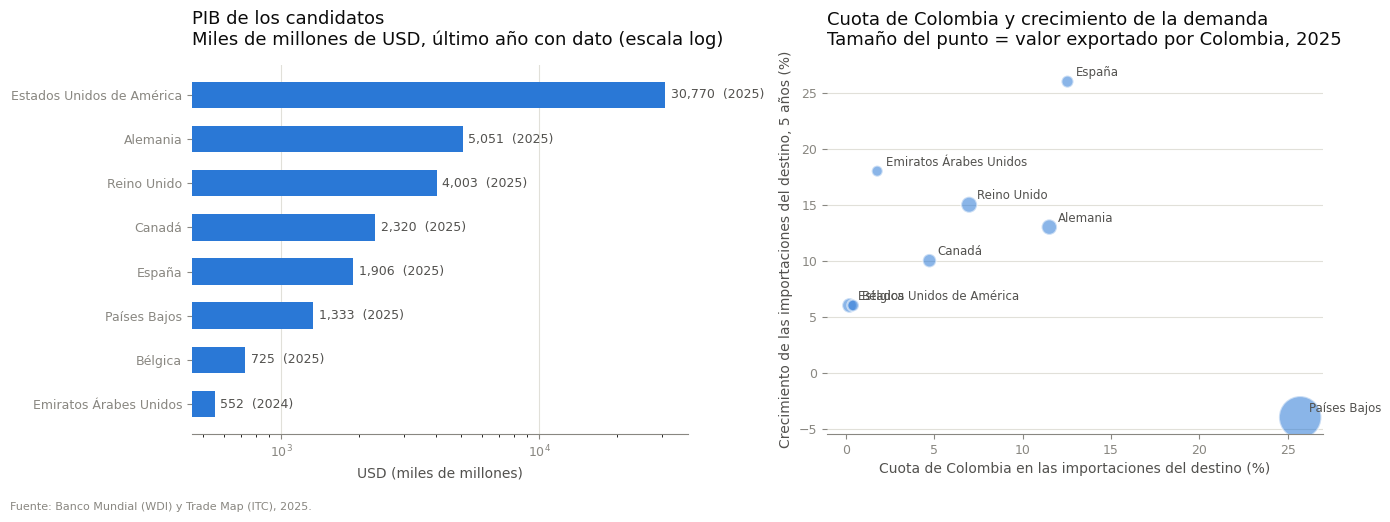

Figura guardada en salidas/g1_candidatos.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = tablero.sort_values("pib_usd_mil_mn")
axes[0].barh(orden.index, orden["pib_usd_mil_mn"], color=AZUL, height=0.6)
for y, (v, a) in enumerate(zip(orden["pib_usd_mil_mn"], orden["anio_pib"])):
    axes[0].annotate(f"{v:,.0f}  ({a:.0f})", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
axes[0].set_xscale("log")
estilo(axes[0], "PIB de los candidatos", "Miles de millones de USD, último año con dato (escala log)", eje_x="USD (miles de millones)", rejilla="x")
puntos = tablero.dropna(subset=["cuota_en_socio_pct", "crec_importaciones_socio_5a_pct"])
tamanos = puntos["valor_kusd"] / puntos["valor_kusd"].max() * 900 + 40
axes[1].scatter(puntos["cuota_en_socio_pct"], puntos["crec_importaciones_socio_5a_pct"], s=tamanos, color=AZUL, alpha=0.55, edgecolor="white", linewidth=1.5)
for nombre, p in puntos.iterrows():
    axes[1].annotate(nombre, (p["cuota_en_socio_pct"], p["crec_importaciones_socio_5a_pct"]), textcoords="offset points", xytext=(6, 4), fontsize=8.5, color=GRIS_TEXT)
estilo(axes[1], "Cuota de Colombia y crecimiento de la demanda", "Tamaño del punto = valor exportado por Colombia, 2025", "Banco Mundial (WDI) y Trade Map (ITC), 2025.",
       eje_x="Cuota de Colombia en las importaciones del destino (%)", eje_y="Crecimiento de las importaciones del destino, 5 años (%)")
plt.tight_layout()
guardar(fig, "g1_candidatos")

**Análisis del equipo:**

La primera gráfica compara el tamaño de las economías de los ocho mercados candidatos. Estados Unidos presenta el PIB más alto, con aproximadamente USD 30.770 mil millones, seguido por Alemania con USD 5.051 mil millones y Reino Unido con USD 4.003 mil millones. Después aparecen Canadá, España, Países Bajos, Bélgica y Emiratos Árabes Unidos.

Sin embargo, tener un PIB alto no convierte automáticamente a un país en el mejor mercado para la uchuva. Por esta razón, la segunda gráfica compara la participación de Colombia en las importaciones del destino, el crecimiento de su demanda durante los últimos cinco años y el valor exportado por Colombia en 2025, representado por el tamaño de cada punto.

Países Bajos es actualmente el principal destino. Colombia exportó cerca de USD 76,3 millones, equivalentes al 65,5 % de sus exportaciones del HS 081090, y tiene una participación del 25,71 % en las importaciones neerlandesas. Sin embargo, la demanda de este país disminuyó un 4 %. Esto muestra que es necesario conservar este mercado, pero también reducir la dependencia que existe frente a él.

Entre las mejores oportunidades se encuentra España, donde la demanda aumentó un 26 % y Colombia ya tiene una participación del 12,54 %. También se destaca Alemania, con un crecimiento de las importaciones del 13 %, una participación colombiana del 11,51 % y exportaciones cercanas a USD 7,2 millones. Por su parte, Reino Unido registró un crecimiento del 15 %, una participación colombiana del 6,97 % y exportaciones aproximadas de USD 8 millones.

Estados Unidos representa una oportunidad diferente. Aunque tiene la economía más grande y su demanda creció un 6 %, Colombia solamente representa el 0,20 % de sus importaciones. Esto indica que existe un mercado amplio todavía poco aprovechado, pero aumentar la participación podría requerir una mayor inversión, promoción y cumplimiento de requisitos comerciales y fitosanitarios.

Otros mercados también muestran oportunidades: las importaciones de Canadá crecieron un 10 %, las de Emiratos Árabes Unidos un 18 % y las de Bélgica un 6 %. Sin embargo, la presencia colombiana en estos destinos todavía es menor que en Alemania, Reino Unido o España.

Se recomienda mantener Países Bajos como mercado principal, pero diversificar las exportaciones hacia Alemania, Reino Unido y España, porque estos países combinan crecimiento de la demanda, participación colombiana y capacidad económica. Estados Unidos puede considerarse un mercado de largo plazo por el tamaño de su economía, aunque requeriría una estrategia de entrada más amplia.

***
# 8. Matriz de mercados

La ficha pide evaluar **al menos cinco mercados** y seleccionar **hasta tres**. Cuatro criterios salen de los datos (valor actual exportado, crecimiento de las importaciones del destino, cuota de Colombia y PIB); dos son **editables** porque requieren ICA, Legiscomex o Analdex: facilidad de acceso fitosanitario y arancel. Los pesos también son editables. Cada criterio se lleva a 0-100 según su dirección.

In [19]:
# ====================== EDITABLE: pesos y criterios manuales ======================
PESOS = {
    "Valor exportado por Colombia 2025": 20,
    "Crecimiento de las importaciones del destino, 5 años": 20,
    "Cuota actual de Colombia": 15,
    "PIB": 15,
    "Facilidad de acceso fitosanitario (1-5)": 15,     # manual: mayor es mejor
    "Arancel a Colombia (%)": 15,                      # manual: menor es mejor
}
MANUAL = pd.DataFrame({
    "Facilidad de acceso fitosanitario (1-5)": [3] * len(CANDIDATOS),
    "Arancel a Colombia (%)": [0] * len(CANDIDATOS),
}, index=list(CANDIDATOS.keys())).T
# ==================================================================================
VARIABLES = pd.DataFrame({
    "Valor exportado por Colombia 2025": tablero["valor_kusd"],
    "Crecimiento de las importaciones del destino, 5 años": tablero["crec_importaciones_socio_5a_pct"],
    "Cuota actual de Colombia": tablero["cuota_en_socio_pct"],
    "PIB": tablero["pib_usd"],
}).T
VARIABLES = pd.concat([VARIABLES, MANUAL]).astype(float)
DIRECCION = {v: +1 for v in VARIABLES.index}
DIRECCION["Arancel a Colombia (%)"] = -1

def a_escala_100(fila, direccion):
    """Min-max a 0-100 en la direccion indicada. Si todos son iguales, 50."""
    if fila.max() == fila.min():
        return pd.Series(50.0, index=fila.index)
    escala = (fila - fila.min()) / (fila.max() - fila.min()) * 100
    return escala if direccion > 0 else 100 - escala

PUNTAJES = pd.DataFrame({v: a_escala_100(VARIABLES.loc[v], DIRECCION[v]) for v in VARIABLES.index}).T
matriz = matriz_multicriterio(PUNTAJES, PESOS)
print("Variables crudas:"); display(VARIABLES.round(2))
exportar(matriz.reset_index().rename(columns={"index": "mercado"}), "g1_matriz_mercados")
matriz.round(1)

Variables crudas:


,Países Bajos,Reino Unido,Alemania,Estados Unidos de América,Canadá,España,Bélgica,Emiratos Árabes Unidos
Valor exportado por Colombia 2025,"76,271.0000","7,985.0000","7,237.0000","6,222.0000","4,700.0000","3,084.0000","2,623.0000","2,011.0000"
"Crecimiento de las importaciones del destino, 5 años",-4.0000,15.0000,13.0000,6.0000,10.0000,26.0000,6.0000,18.0000
Cuota actual de Colombia,25.7100,6.9700,11.5100,0.2000,4.7300,12.5400,0.4100,1.7700
PIB,"1,332,767,651,100.3899","4,002,587,541,846.0098","5,050,922,925,047.0498","30,769,700,000,000.0000","2,319,899,772,425.9199","1,906,453,309,985.8799","725,466,462,859.6500","552,324,919,095.8700"
Facilidad de acceso fitosanitario (1-5),3.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000
Arancel a Colombia (%),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,Valor exportado por Colombia 2025,"Crecimiento de las importaciones del destino, 5 años",Cuota actual de Colombia,PIB,Facilidad de acceso fitosanitario (1-5),Arancel a Colombia (%),Total
Países Bajos,20.0000,0.0000,15.0000,0.4000,7.5000,7.5000,50.4000
España,0.3000,20.0000,7.3000,0.7000,7.5000,7.5000,43.2000
Estados Unidos de América,1.1000,6.7000,0.0000,15.0000,7.5000,7.5000,37.8000
Alemania,1.4000,11.3000,6.7000,2.2000,7.5000,7.5000,36.6000
Reino Unido,1.6000,12.7000,4.0000,1.7000,7.5000,7.5000,35.0000
Emiratos Árabes Unidos,0.0000,14.7000,0.9000,0.0000,7.5000,7.5000,30.6000
Canadá,0.7000,9.3000,2.7000,0.9000,7.5000,7.5000,28.6000
Bélgica,0.2000,6.7000,0.1000,0.1000,7.5000,7.5000,22.0000


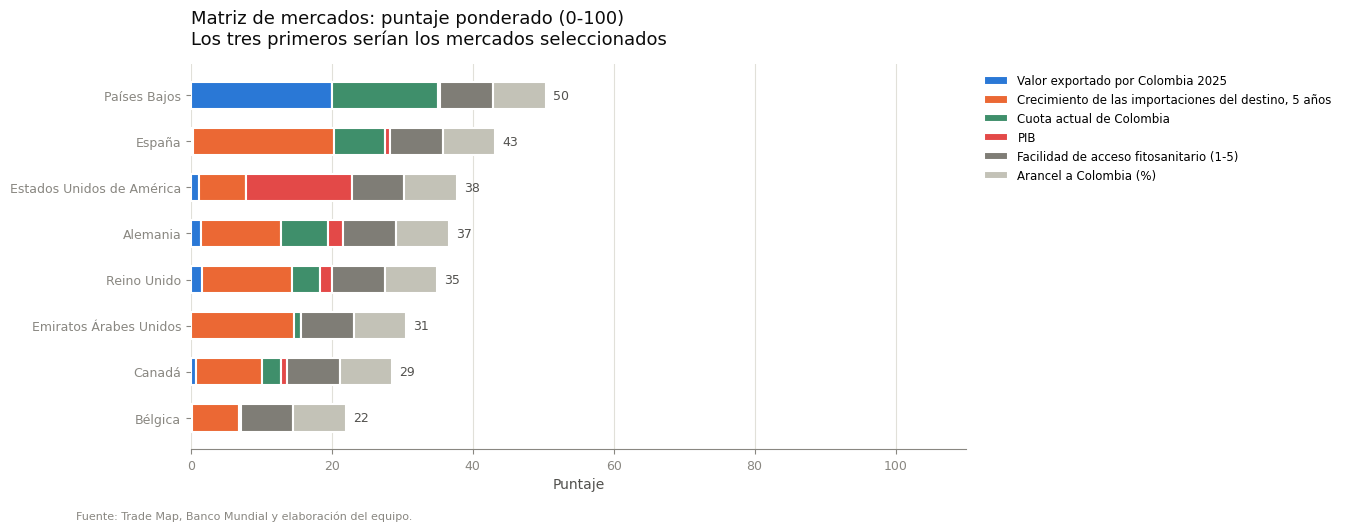

Figura guardada en salidas/g1_matriz_mercados.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
acumulado = np.zeros(len(matriz))
paleta = CATEGORIAS + ["#7f7d76", GRIS_MID]
for color, criterio in zip(paleta, PESOS.keys()):
    ax.barh(matriz.index, matriz[criterio], left=acumulado, color=color, height=0.6, label=criterio, edgecolor="white", linewidth=1.5)
    acumulado += matriz[criterio].values
for y, t in enumerate(matriz["Total"]):
    ax.annotate(f"{t:.0f}", (t, y), textcoords="offset points", xytext=(5, 0), va="center", fontsize=9, color=GRIS_TEXT)
ax.invert_yaxis()
ax.set_xlim(0, 110)
leyenda_fuera(ax)
estilo(ax, "Matriz de mercados: puntaje ponderado (0-100)", "Los tres primeros serían los mercados seleccionados", "Trade Map, Banco Mundial y elaboración del equipo.", eje_x="Puntaje", rejilla="x")
guardar(fig, "g1_matriz_mercados")

**Análisis del equipo:** ¿Cuáles tres mercados quedan seleccionados y qué cambia si llenan los criterios manuales con datos del ICA y Legiscomex?

La matriz ponderada ubica a Países Bajos (50/100), España (43/100) y Estados Unidos (38/100) como los tres mercados seleccionados con los criterios actuales. Este resultado está determinado casi en su totalidad por los cuatro criterios de datos (valor exportado, crecimiento, cuota y PIB), porque facilidad fitosanitaria y arancel todavía tienen el mismo valor para los ocho candidatos y por lo tanto no inciden en el orden.

Cada mercado llega al top 3 por una razón distinta. Países Bajos domina por su posición ya consolidada (mayor valor exportado y mayor cuota de Colombia), pero su crecimiento de importaciones es negativo (-4% a 5 años), lo que sugiere un mercado maduro y posiblemente saturado, coherente con la concentración ya identificada en la Sección 3. España entra en segundo lugar casi exclusivamente por tener el mayor crecimiento de importaciones del grupo (26%), pese a representar hoy un volumen pequeño (US$3 millones): es la señal más clara de mercado emergente. Estados Unidos aparece en tercer lugar por el peso de su PIB, aunque su cuota actual es prácticamente nula (0,2%), es decir, es potencial sin explotar más que una relación comercial madura.

Al reemplazar el arancel de ejemplo por el dato real, el resultado no cambia: los ocho mercados tienen arancel 0% gracias a los TLC vigentes con la Unión Europea, Reino Unido, Estados Unidos y Canadá, y a la exención del Consejo de Cooperación del Golfo para fruta fresca en Emiratos Árabes Unidos. El cambio real aparece en la facilidad de acceso fitosanitario: al diferenciar los mercados con protocolos maduros (Unión Europea, Reino Unido, Canadá) de los de acceso más reciente o menos consolidado (Estados Unidos, con requisito de altitud y eliminación apenas en 2021 del tratamiento en frío; Emiratos Árabes Unidos, sin protocolo bilateral específico identificado), Alemania (44/100) desplaza a Estados Unidos (38/100) del tercer puesto.

Esto habilita una decisión diferenciada por mercado, no una estrategia única: en Países Bajos, una estrategia defensiva de mantenimiento de valor y diversificación de compradores dado el riesgo de concentración; en España, inversión comercial activa para capturar el crecimiento antes que otros competidores; y en Alemania, desarrollo de mercado de mediano plazo, aprovechando el acceso arancelario ya garantizado por el TLC vigente.


***
# 9. Cadena de valor, actores y requisitos (OE4)

Este objetivo es cualitativo (EMIS, ICA, Analdex, Legiscomex) y no lleva código.

**Mapa de actores y requisitos del equipo:**

Producción: pequeños y medianos productores concentrados en Cundinamarca, Boyacá, Antioquia y Bogotá, que deben aplicar Buenas Prácticas Agrícolas y estar registrados como predios exportadores ante el ICA.  
Comercialización y exportación: comercializadoras internacionales que concentran el grueso de las ventas, como Frutireyes S.A.S. (la de mayor participación), Colombia Paradise S.A.S., Frutas Comerciales S.A., Caribbean Exotics S.A.S. y Novacampo S.A.S.  
Gremios y promoción: el Comité de Exportadores de Uchuva (creado en 2014 bajo Analdex), que coordina el acceso a mercados internacionales; ProColombia, en promoción comercial e inteligencia de mercados; y Asohofrucol y Agrosavia, en acompañamiento técnico e investigación al sector productivo.  
Autoridades sanitarias: el ICA, que inspecciona los predios exportadores y vigila el cumplimiento de la Resolución 8461 de 2019 (plan fitosanitario contra moscas de la fruta); y, del lado del país destino, la contraparte sanitaria correspondiente (por ejemplo, USDA-APHIS para Estados Unidos).  
Política comercial: el Ministerio de Agricultura y Desarrollo Rural y el Ministerio de Comercio, Industria y Turismo, responsables de los TLC que sustentan el acceso arancelario preferencial (0% en Unión Europea, Reino Unido, Estados Unidos y Canadá).  
Requisitos por eslabón: certificado fitosanitario del ICA por embarque; límites máximos de residuos de agroquímicos (más estrictos en la Unión Europea); certificaciones voluntarias cada vez más exigidas por compradores (GlobalG.A.P., HACCP, Comercio Justo); en Estados Unidos, cultivo por encima de 2.200 msnm bajo el protocolo bilateral ICA-APHIS; y, en general, cadena de frío y logística adecuada para un producto altamente perecedero.


***
# Entrega

1. Revisa que todas las celdas **Análisis del equipo** tengan texto.  
2. `Archivo → Descargar → Descargar .ipynb`.  
3. Sube el archivo al aula virtual. Las figuras y tablas de `salidas/` pueden ir al informe escrito.

# Referencias

Balassa, B. (1965). Trade liberalisation and "revealed" comparative advantage. *The Manchester School, 33*(2), 99–123.

World Bank. (2025). *World Development Indicators*. https://data.worldbank.org

Baena-Rojas, J. J., & Cano, J. A. (2026). International market selection for exports of goods: A data analysis technique for organizational decision-making. *Global Business Review*. https://doi.org/10.1177/09721509261464305

International Trade Centre. (2025). *Trade Map: Trade statistics for international business development*. https://www.trademap.org

Durán Lima, J. E. (s.f.). *Indicadores de comercio exterior y política comercial: Generalidades metodológicas e indicadores básicos*. CEPAL.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55


::: {.pie-ean}
**Equipo 1 · Uchuva fresca · HS 081090** · Proyecto final de Inteligencia en Negocios Globales, Universidad EAN, septiembre de 2026. Docente: Alejandra Otero. Sitio construido con [Quarto](https://quarto.org) a partir del cuaderno de análisis del equipo.
:::
